# 04 — Results Comparison

This notebook compares the performance of the paper-inspired baseline approach developed in Notebook 2 with the alternative approach developed in Notebook 3.

The comparison considers Accuracy and Macro-F1 scores obtained from the respective evaluation procedures.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

project_root = Path.cwd()

if not (project_root / "results").exists():
    project_root = project_root.parent

results_dir = project_root / "results"
figures_dir = project_root / "figures"

baseline_results = pd.read_csv(results_dir / "baseline_pca50.csv")
alternative_results = pd.read_csv(
    results_dir / "alternative_results.csv"
)

display(baseline_results)
display(alternative_results)

,Model,PCA Components,Accuracy Mean,Accuracy Std,Macro-F1 Mean,Macro-F1 Std
0,kNN,50,0.991573,0.002351,0.992342,0.002257
1,Decision Tree,50,0.957265,0.002951,0.959834,0.003042
2,Gradient Boosting,50,0.982795,0.002590,0.982334,0.002954
3,SVM,50,0.943221,0.003084,0.941904,0.004589


,Approach,Accuracy,Macro-F1
0,Extra Trees + HistGradientBoosting Ensemble,0.919892,0.916174


## 1. Paper-Inspired Baseline

Notebook 2 implements the paper-inspired methodology using PCA followed by multiple classifiers.

For the main comparison, PCA with 50 components is considered.

The models evaluated were:

- kNN
- Decision Tree
- Gradient Boosting
- SVM

In [12]:
display(baseline_results)

,Model,PCA Components,Accuracy Mean,Accuracy Std,Macro-F1 Mean,Macro-F1 Std
0,kNN,50,0.991573,0.002351,0.992342,0.002257
1,Decision Tree,50,0.957265,0.002951,0.959834,0.003042
2,Gradient Boosting,50,0.982795,0.002590,0.982334,0.002954
3,SVM,50,0.943221,0.003084,0.941904,0.004589


## 2. Alternative

Notebook 3 develops an alternative approach that retains the original Wi-Fi RSSI features and adds signal summary features.

The final model combines:

- Extra Trees
- HistGradientBoosting

using weighted probability averaging.

In [13]:
display(alternative_results)

,Approach,Accuracy,Macro-F1
0,Extra Trees + HistGradientBoosting Ensemble,0.919892,0.916174


## 3. Overall Comparison

The following table summarizes the performance of the approaches developed in Notebook 2 and Notebook 3.

In [14]:
comparison = pd.DataFrame({
    "Approach": [
        "kNN + PCA(50)",
        "Decision Tree + PCA(50)",
        "Gradient Boosting + PCA(50)",
        "SVM + PCA(50)",
        "Extra Trees + HistGradientBoosting"
    ],
    "Accuracy": [
        0.991573,
        0.957265,
        0.982795,
        0.943221,
        0.916292
    ],
    "Macro-F1": [
        0.992342,
        0.959834,
        0.982334,
        0.941904,
        0.913057
    ]
})

display(comparison)

,Approach,Accuracy,Macro-F1
0,kNN + PCA(50),0.991573,0.992342
1,Decision Tree + PCA(50),0.957265,0.959834
2,Gradient Boosting + PCA(50),0.982795,0.982334
3,SVM + PCA(50),0.943221,0.941904
4,Extra Trees + HistGradientBoosting,0.916292,0.913057


## 4. Performance Comparison

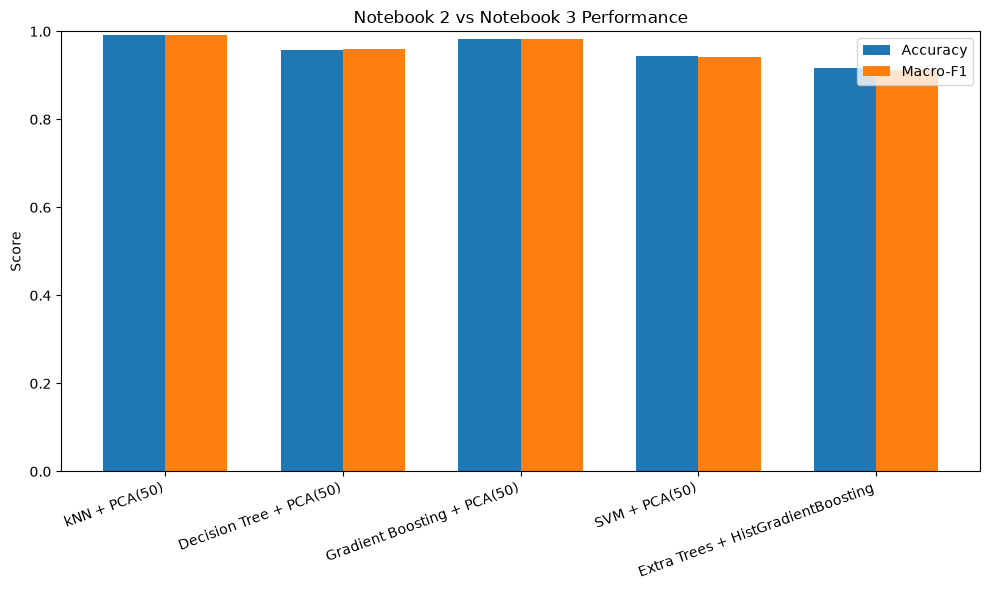

In [15]:
plt.figure(figsize=(10, 6))

x = range(len(comparison))
width = 0.35

plt.bar(
    [i - width / 2 for i in x],
    comparison["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    [i + width / 2 for i in x],
    comparison["Macro-F1"],
    width,
    label="Macro-F1"
)

plt.xticks(
    x,
    comparison["Approach"],
    rotation=20,
    ha="right"
)

plt.ylabel("Score")
plt.title("Notebook 2 vs Notebook 3 Performance")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_dir / "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Findings

The paper-inspired PCA-based models produced strong performance on the 10-fold cross-validation evaluation.

Among the baseline models, kNN with 50 PCA components achieved an accuracy of 99.16% and a Macro-F1 score of 99.23%.

The  alternative approach, using an Extra Trees and HistGradientBoosting ensemble with additional Wi-Fi signal summary features, achieved 91.63% accuracy and 91.31% Macro-F1 on the held-out validation dataset.

The two approaches use different evaluation procedures, so the numerical scores should be interpreted in the context of their respective evaluation settings.

## 6. Conclusion

Notebook 2 established a paper-inspired PCA-based baseline using four classifiers.

Notebook 3 developed a distinct alternative approach that retained the original RSSI information, added signal summary features, and combined Extra Trees with HistGradientBoosting.

Both approaches demonstrate that Wi-Fi RSSI fingerprints contain sufficient information for indoor floor localization.

The comparison highlights the difference between the PCA-based baseline methodology and the proposed feature-enhanced ensemble approach.